# Data Scraping, Intro - Lane A (the real experience: you prompt, the agent builds)

**SISMID 2026 - Day 1, 9:45 session.** You drive a coding agent - **Codex**,
**Claude Code**, or **Antigravity CLI** - and keep the judgment. For each step:
read the goal, paste the **prompt** into your agent, run the code it writes into the
cell below, and apply the **check** yourself.

> Each prompt produces roughly the matching cell in the **Lane B** notebook. If your
> agent is not set up yet, use Lane B and come back; you will not be blocked.

Target: **Google Dengue Trends for Mexico**: a small live pull of a handful of terms
over the past 5 years, plus the historical 2004-2011 window that feeds the 11:00 exercise.


## Step 0: point the agent at the task

> *In this repo I want to scrape Google Trends with the `pytrends` library (already in*
> *requirements.txt). Write `gt_fetch(kw_list, timeframe, geo='MX')` returning a tidy*
> *DataFrame (`date` + one column per term, underscored names). Build TrendReq with*
> *`retries=3, backoff_factor=0.5`, add a small random `time.sleep` before the call so a*
> *classroom does not all hit Google at once. On a 429, wait ~10s and retry a few*
> *times; return `None` (do not raise) only if it still fails. Also write a loader for the cache `data/google_trends_dengue_mx_cached.csv`.*


In [5]:
"""Small, classroom-friendly helpers for fetching Google Trends data."""

from pathlib import Path
import random
import time

import pandas as pd
from pytrends.request import TrendReq


CACHE_FILENAME = "google_trends_dengue_mx_cached.csv"


def _underscored_name(name):
    """Return a stable, notebook-friendly column name."""
    return name.strip().replace(" ", "_")


def _is_rate_limited(error):
    """Recognize the error forms pytrends uses for HTTP 429 responses."""
    return "429" in str(error) or "toomany" in type(error).__name__.lower()


def gt_fetch(kw_list, timeframe, geo="MX", tries=4):
    """Fetch Google Trends interest over time, returning ``None`` after failure.

    Results have a ``date`` column and one underscored column per requested term.
    A short random pause avoids a synchronized classroom request burst; 429 responses
    are retried after roughly ten seconds.
    """
    time.sleep(random.uniform(0, 3))

    for attempt in range(tries):
        try:
            trends = TrendReq(hl="en-US", tz=360, retries=3, backoff_factor=0.5)
            trends.build_payload(kw_list, timeframe=timeframe, geo=geo)
            frame = trends.interest_over_time()
            if frame.empty:
                return None

            frame = frame.drop(columns=["isPartial"], errors="ignore").reset_index()
            return frame.rename(columns={column: _underscored_name(column) for column in frame.columns})
        except Exception as error:
            if _is_rate_limited(error) and attempt < tries - 1:
                print(f"Rate-limited (attempt {attempt + 1}/{tries}); waiting 10s and retrying...")
                time.sleep(10)
                continue
            print(f"Live Google Trends pull failed ({type(error).__name__}): {error}")
            return None

    return None


def _default_cache_path():
    """Find the bundled cache relative to the notebook's working directory."""
    candidates = []
    for directory in (Path.cwd(), *Path.cwd().parents):
        candidates.extend(
            [
                directory / "data" / CACHE_FILENAME,
                directory
                / "day1-0945-agent-coding-introduction"
                / "data"
                / CACHE_FILENAME,
            ]
        )

    return next((path for path in candidates if path.exists()), candidates[0])


def load_hist_cache(cache_path=None):
    """Load the bundled Mexico dengue Trends snapshot with parsed dates."""
    cache_path = _default_cache_path() if cache_path is None else Path(cache_path)
    return pd.read_csv(cache_path, parse_dates=["date"])


## Step 1: see it *live* (a handful of terms, past 5 years)

> *Use gt_fetch to pull a handful of terms - 'dengue', 'sintomas de dengue', 'mosquito'*
> *- for Mexico over the past five years (timeframe 'today 5-y'). Plot all three and*
> *print the date of the last point.*

**Your check:** does the last point land on the current week? It should. Keep the live
pull to a handful of terms; that is what stays under Google's rate limit.


rows: 262 | last data point: 2026-07-19


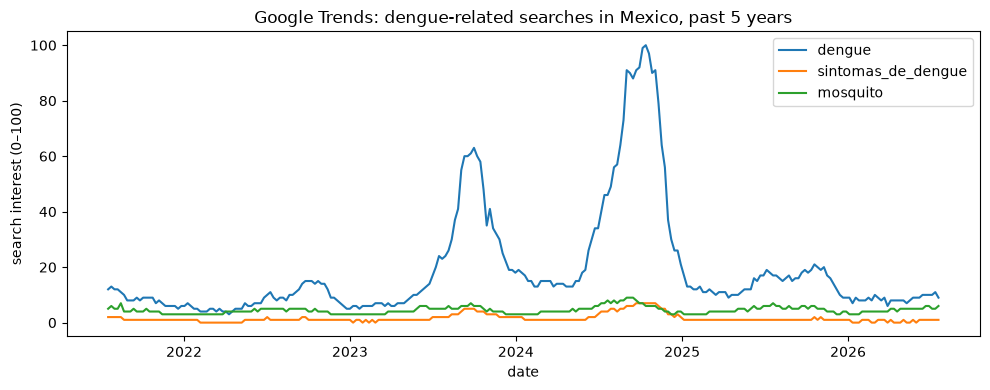

,date,dengue,sintomas_de_dengue,mosquito
257,2026-06-21,10,1,6
258,2026-06-28,10,1,6
259,2026-07-05,10,1,5
260,2026-07-12,11,1,5
261,2026-07-19,9,1,6


In [6]:
# Agent's live handful pull (past 5 years):
import matplotlib.pyplot as plt

terms = ['dengue', 'sintomas de dengue', 'mosquito']
live = gt_fetch(terms, timeframe='today 5-y', geo='MX')

if live is None:
    print('Google Trends is still rate-limiting this request; try again shortly.')
else:
    print(f'rows: {len(live)} | last data point: {live["date"].max().date()}')
    plt.figure(figsize=(10, 4))
    for column in live.columns.drop('date'):
        plt.plot(live['date'], live[column], label=column)
    plt.title('Google Trends: dengue-related searches in Mexico, past 5 years')
    plt.xlabel('date')
    plt.ylabel('search interest (0–100)')
    plt.legend()
    plt.tight_layout()
    plt.show()
    display(live.tail())


## Step 2: the instability note

> *Pull 'dengue' for Mexico twice with the same recent window, merge on date, and report*
> *whether the two pulls are identical and their mean absolute difference.*

Differences are usually small on the public 0-100 endpoint and large on the raw Health
Trends API. Make the agent show you the number rather than take 'done' on faith.


In [7]:
# Agent's twice-pulled comparison:
first = gt_fetch(['dengue'], timeframe='today 5-y', geo='MX')
second = gt_fetch(['dengue'], timeframe='today 5-y', geo='MX')

if first is None or second is None:
    print('Could not compare live pulls because Google rate-limited one of them.')
else:
    comparison = first.merge(second, on='date', suffixes=('_first', '_second'))
    difference = (comparison['dengue_first'] - comparison['dengue_second']).abs()
    print('identical pulls:', bool((difference == 0).all()))
    print('mean absolute difference:', round(difference.mean(), 2))


identical pulls: True
mean absolute difference: 0.0


## Step 3: the historical window for 11:00

> *Now pull four terms ('dengue', 'sintomas de dengue', 'mosquito', 'dengue sintomas')*
> *for Mexico over 2004-01-01 to 2011-12-31. If the live pull returns None, fall back to*
> *the historical cache loader. Merge into one tidy frame and overlay all four terms.*


rows: 96 | 2004-01-01 to 2011-12-01


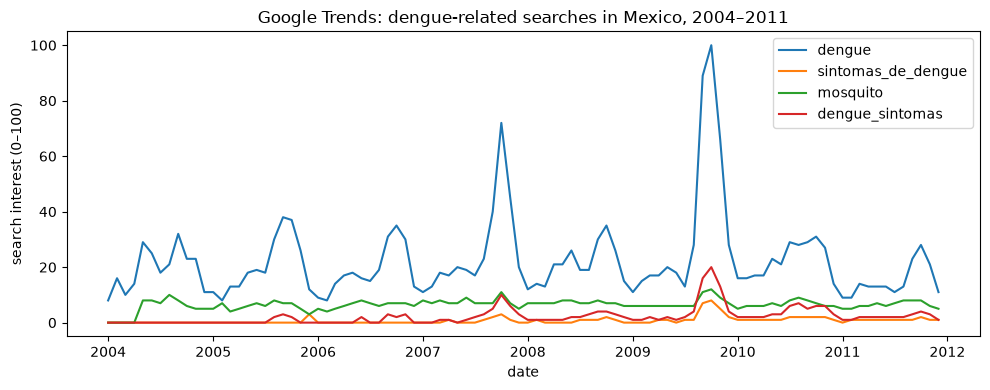

,date,dengue,sintomas_de_dengue,mosquito,dengue_sintomas
0,2004-01-01,8,0,0,0
1,2004-02-01,16,0,0,0
2,2004-03-01,10,0,0,0
3,2004-04-01,14,0,0,0
4,2004-05-01,29,0,8,0


In [8]:
# Agent's historical pull with cache fallback:
import matplotlib.pyplot as plt

historical_terms = ['dengue', 'sintomas de dengue', 'mosquito', 'dengue sintomas']
historical = gt_fetch(
    historical_terms,
    timeframe='2004-01-01 2011-12-31',
    geo='MX',
)

if historical is None:
    print('Using the historical cache after the live pull failed.')
    historical = load_hist_cache()

# `historical` is one tidy frame: date plus one underscored column per term.
print(f'rows: {len(historical)} | {historical["date"].min().date()} to {historical["date"].max().date()}')
plt.figure(figsize=(10, 4))
for column in historical.columns.drop('date'):
    plt.plot(historical['date'], historical[column], label=column)
plt.title('Google Trends: dengue-related searches in Mexico, 2004–2011')
plt.xlabel('date')
plt.ylabel('search interest (0–100)')
plt.legend()
plt.tight_layout()
plt.show()
display(historical.head())


## Step 4: sanity-check and save

> *Report the date range, row count, and missing values per column, show which terms*
> *vary, then save the historical four-term table to `dengue_mx_search.csv` and confirm.*


In [9]:
# Agent's sanity-check + save:
term_columns = historical.columns.drop('date')
print('date range:', historical['date'].min().date(), 'to', historical['date'].max().date())
print('row count:', len(historical))
print('missing values per column:')
print(historical.isna().sum())

unique_counts = historical[term_columns].nunique(dropna=True)
varying_terms = unique_counts[unique_counts > 1]
print('varying terms (unique values):')
print(varying_terms)

output_path = 'dengue_mx_search.csv'
historical.to_csv(output_path, index=False)
print(f'Saved {len(historical)} rows to {output_path}.')


date range: 2004-01-01 to 2011-12-01
row count: 96
missing values per column:
date                  0
dengue                0
sintomas_de_dengue    0
mosquito              0
dengue_sintomas       0
dtype: int64
varying terms (unique values):
dengue                32
sintomas_de_dengue     7
mosquito              11
dengue_sintomas       12
dtype: int64
Saved 96 rows to dengue_mx_search.csv.


## Reflection

- You described **outcomes and checks**; the agent wrote the `pytrends` plumbing.
- The judgment stayed with you: is the last point current, do repeat pulls differ, do
  the peaks fall in a plausible dengue season.
- **Next session (11:00):** model this exact signal against reported dengue cases.

**Stretch:** ask the agent to swap `geo` and the handful of terms for your own country
and disease, and rebuild the notebook from a one-paragraph description.


Rate-limited (attempt 1/4); waiting 10s and retrying...
rows: 134 | last data point: 2026-07-19


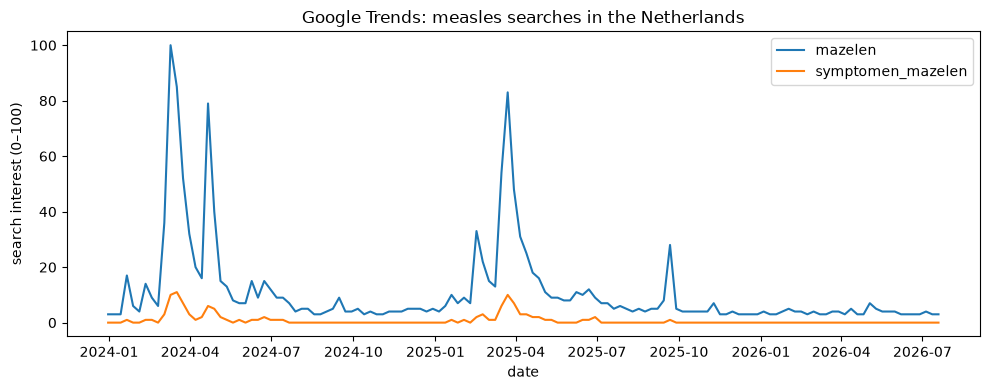

,date,mazelen,symptomen_mazelen
129,2026-06-21,3,0
130,2026-06-28,3,0
131,2026-07-05,4,0
132,2026-07-12,3,0
133,2026-07-19,3,0


In [10]:
# Netherlands measles searches, from 2024 through today.
from datetime import date
import matplotlib.pyplot as plt

nl_terms = ['mazelen', 'symptomen mazelen']
nl_timeframe = f'2024-01-01 {date.today().isoformat()}'
nl_measles = gt_fetch(nl_terms, timeframe=nl_timeframe, geo='NL')

if nl_measles is None:
    print('Google Trends did not return data; try the live pull again shortly.')
else:
    print(f'rows: {len(nl_measles)} | last data point: {nl_measles["date"].max().date()}')
    plt.figure(figsize=(10, 4))
    for column in nl_measles.columns.drop('date'):
        plt.plot(nl_measles['date'], nl_measles[column], label=column)
    plt.title('Google Trends: measles searches in the Netherlands')
    plt.xlabel('date')
    plt.ylabel('search interest (0–100)')
    plt.legend()
    plt.tight_layout()
    plt.show()
    display(nl_measles.tail())
